In [1]:
from IPython.display import Image
import xarray as xr
import numpy as np
import math
import cartopy.crs as ccrs # for geographic plotting
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from global_land_mask import globe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from matplotlib.colors import to_hex
import glob
import os
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
  # Indispensable pour regriller facilement les grilles océaniques CMIP6
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- 1. Définition des Chemins (Tes dictionnaires) ---
# need tos, tas, ua, va, hus, ps

dict_tos = {
    #"EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Omon/tos/gn/v20200918/",
    #"EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Omon/tos/gn/v20200919/",
    #"ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Omon/tos/gn/latest/",
    #"SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Omon/tos/gn/v20190910/", 
    #"GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Omon/tos/gr/v20180701/",
    #"GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Omon/tos/gr/v20190201/",
    #"NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Omon/tos/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Omon/tos/gn/v20190904/",
    #"UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Omon/tos/gn/v20200828/",
    #"HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Omon/tos/gn/v20190628/",
}

dict_tas = {
    #"EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/tas/gr/v20200312/",
    #"EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/tas/gr/v20200213/",
    #"ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/tas/gn/latest/",
    #"SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/tas/gn/v20190910/", 
    #"GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/tas/gr1/v20180701/",
    #"GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/tas/gr1/v20180701/",    
    #"NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/tas/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/tas/gn/v20190222/",
    #"UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/tas/gn/v20200828/",
    #"HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/tas/gn/v20190628/",
}

dict_ua = {
    #"EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/ua/gr/v20200312/",
    #"EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/ua/gr/v20200213/",
    #"ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/ua/gn/latest/",
    #"SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/ua/gn/v20190910/", 
    #"GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/ua/gr1/v20180701/",
    #"GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/ua/gr1/v20180701/",
    #"NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/ua/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/ua/gn/v20190308/",
    #"UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/ua/gn/v20200828/",
    #"HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/ua/gn/v20190628/",
}

dict_va = {
    #"EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/va/gr/v20200312/",
    #"EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/va/gr/v20200213/",
    #"ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/va/gn/latest/",
    #"SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/va/gn/v20190910/", 
    #"GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/va/gr1/v20180701/",
    #"GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/va/gr1/v20180701/",
    #"NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/va/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/va/gn/v20190308/",
    #"UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/va/gn/v20200828/",
    #"HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/va/gn/v20190628/",
}

dict_hus = {
    #"EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/hus/gr/v20200312/",
    #"EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/hus/gr/v20200213/",
    #"ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/hus/gn/latest/",
    #"SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/hus/gn/v20190910/", 
    #"GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/hus/gr1/v20180701/",
    #"GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/hus/gr1/v20180701/",
    #"NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/hus/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/hus/gn/v20190308/",
    #"UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/hus/gn/v20200828/",
    #"HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/hus/gn/v20190628/",
}

dict_ps = {
    #"EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/ps/gr/v20200312/",
    #"EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/ps/gr/v20200213/",
    #"ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/ps/gn/latest/",
    #"SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/ps/gn/v20190910/", 
    #"GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/ps/gr1/v20180701/",
    #"GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/ps/gr1/v20180701/",
    #"NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/ps/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/ps/gn/v20190222/",
    #"UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/ps/gn/v20200828/",
    #"HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/ps/gn/v20190628/",
}

dict_ev = {
    #"EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/evspsbl/gr/v20201122/",
    #"EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/evspsbl/gr/v20201122/",
    #"ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/evspsbl/gn/latest/",
    #"SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/evspsbl/gn/v20190910/", 
    #"GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/evspsbl/gr1/v20180701/",
    #"GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/evspsbl/gr1/v20180701/",
    #"NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/evspsbl/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/evspsbl/gn/v20190222/",
    #"UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/evspsbl/gn/v20200828/",
    #"HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/evspsbl/gn/v20190628/",
}

# --- 3. Définition des bornes géographiques ---
lat_b = (-23, -11) # Nord Australie
lon_b = (122, 149)

# --- 4. Fonction de Detrending (Même que pour les obs) ---
def apply_detrend(da_ts, window=240):
    # rolling avec min_periods=1 pour gérer les bords sans NaN excessifs au début
    moyenne_mobile = da_ts.rolling(time=window, center=True, min_periods=1).mean()
    da_detrended = da_ts - moyenne_mobile
    return da_detrended

In [3]:
# --- 1. Chargement du catalogue ---
csv_path = '/g/data/m35/qr1706/PhD-1_CMIP_analysis/csv_npy/triple_lanina_catalog_sp.csv'
df_triples = pd.read_csv(csv_path)

# Liste des modèles étudiés
modeles = ['MRI-ESM2-0']#, 'EC-Earth3', 'EC-Earth3-Veg-LR', 'ACCESS-ESM1-5', 
           #'SAMO-UNICON', 'GFDL-ESM4', 'GFDL-CM4', 'NorESM2-MM', 'UKESM1-0-LL', 'HadGEM3-GC31-LL']

# --- 3. Création de la grille commune (ex: 2°x2° sur la zone d'intérêt) ---
# Nécessaire pour faire la moyenne de modèles ayant des résolutions différentes
ds_out = xr.Dataset({
    'lat': (['lat'], np.arange(-45, 10, 2.0)),
    'lon': (['lon'], np.arange(80, 180, 2.0)),
})

In [8]:
#Cellule 3
from scipy.interpolate import griddata
def standardize_cmip_coords(da):
    """Standardise les noms des coordonnées pour un DataArray ou Dataset."""
    coords_map = {'latitude': 'lat', 'nav_lat': 'lat', 'lat2d': 'lat',
                  'longitude': 'lon', 'nav_lon': 'lon', 'lon2d': 'lon'}
    
    # On renomme les coordonnées si elles existent
    for old_c, new_c in coords_map.items():
        if old_c in da.coords:
            da = da.rename({old_c: new_c})
            
    # Gestion des longitudes 0-360
    if 'lon' in da.coords and da.lon.max() <= 180.1:
        da.coords['lon'] = (da.coords['lon'] + 360) % 360
        if da.lon.ndim == 1:
            da = da.sortby('lon')
            
    return da

def regrid_to_common(da, ds_out):
    import numpy as np
    from scipy.interpolate import griddata

    # 1. Préparation grille cible
    lon_target, lat_target = np.meshgrid(ds_out.lon.values, ds_out.lat.values)
    
    # 2. Préparation grille source : on s'assure que tout a la même forme
    # On récupère les coordonnées sous forme de tableaux numpy simples
    lats_src = da.lat.values
    lons_src = da.lon.values
    data_src = da.values

    # Si c'est du 1D (rectiligne), on en fait du 2D pour uniformiser le traitement
    if lats_src.ndim == 1:
        lons_src, lats_src = np.meshgrid(lons_src, lats_src)

    # Aplatissement systématique pour scipy
    lon_flat = lons_src.flatten()
    lat_flat = lats_src.flatten()

    regridded_frames = []
    
    # Boucle temporelle
    for i in range(data_src.shape[0]):
        frame_flat = data_src[i].flatten()
        
        # --- LA RÉPARATION ---
        # On s'assure que le masque est calculé sur la forme aplatie COMBINÉE
        # Cela évite l'erreur de broadcast
        mask = ~np.isnan(frame_flat) & ~np.isnan(lon_flat) & ~np.isnan(lat_flat)
        
        if not np.any(mask):
            grid_z = np.full(lon_target.shape, np.nan)
        else:
            grid_z = griddata(
                (lon_flat[mask], lat_flat[mask]), 
                frame_flat[mask], 
                (lon_target, lat_target), 
                method='linear'
            )
        regridded_frames.append(grid_z)

    return xr.DataArray(
        np.array(regridded_frames),
        coords={'time': da.time, 'lat': ds_out.lat, 'lon': ds_out.lon},
        dims=['time', 'lat', 'lon'],
        name=da.name if hasattr(da, 'name') else 'var'
    )
def calculate_vimd_native(da_hus, da_ua, da_va, da_ps):
    g = 9.80665

    def to_pa(da):
        if 'plev' in da.coords:
            if float(da.plev.max().values) < 5000:
                return da.assign_coords(plev=da.plev * 100)
        return da

    q = to_pa(da_hus)
    u = to_pa(da_ua)
    v = to_pa(da_va)

    if 'units' in da_ps.attrs and da_ps.attrs['units'] in ['hPa', 'mbar']:
        ps = da_ps * 100
    else:
        ps_sample = float(da_ps.isel(time=0, lat=0, lon=0).values)
        ps = da_ps * 100 if ps_sample < 5000 else da_ps

    q, u, v = xr.align(q, u, v, join='override')
    ps = ps.interp(lat=q.lat, lon=q.lon, method='nearest')

    # Remplissage NaNs (points terrestres) avant l'intégrale
    q = q.fillna(0.0)
    u = u.fillna(0.0)
    v = v.fillna(0.0)

    mask_above = q.plev <= ps
    qu = (q * u).where(mask_above, 0.0).sortby('plev').integrate('plev') / g
    qv = (q * v).where(mask_above, 0.0).sortby('plev').integrate('plev') / g

    return qu, qv

def get_event_season_anomaly(da_anom, start_year, season='SON'):
    years = da_anom.time.dt.year

    if season == 'SON':
        mask = (years == start_year) & (da_anom.time.dt.month.isin([9, 10, 11]))
    elif season == 'DJF':
        mask = (
            ((years == start_year)     & (da_anom.time.dt.month == 12)) |
            ((years == start_year + 1) & (da_anom.time.dt.month.isin([1, 2])))
        )
    else:
        raise ValueError(f"Saison {season} non gérée.")

    da_season = da_anom.sel(time=mask)
    if len(da_season.time) == 0:
        return None
    return da_season.mean(dim='time')

def preprocess_cmip(ds):
    """
    Nettoie le dataset lors de l'ouverture :
    - Supprime les variables de bordures qui font planter la concaténation.
    - Uniformise les noms de latitudes et longitudes.
    """
    # Liste des variables de coordonnées auxiliaires qui causent souvent des erreurs
    vars_to_drop = ['time_bnds', 'lat_bnds', 'lon_bnds', 'vertices_latitude', 'vertices_longitude', 'height']
    ds = ds.drop_vars(vars_to_drop, errors='ignore')
    
    # Correction spécifique pour l'évaporation si elle est présente
    if 'evspsbl' in ds.data_vars:
        # Dans CMIP6, evspsbl est en kg/m2/s. On veut mm/day
        # On multiplie par 86400. 
        # Note : On ne le fait ici que si on veut que TOUT le dataset soit converti d'un coup.
        pass 
        
    return ds

def crop_zone_robust(ds):
    """ Réduit le dataset à la zone d'étude en détectant les noms de coordonnées """
    # Détection dynamique des noms
    lat_key = [k for k in ['lat', 'latitude', 'nav_lat'] if k in ds.coords or k in ds.dims]
    lon_key = [k for k in ['lon', 'longitude', 'nav_lon'] if k in ds.coords or k in ds.dims]
    
    if not lat_key or not lon_key:
        return ds # On ne peut pas cropper si on ne trouve rien
        
    return ds.sel({
        lat_key[0]: slice(-45, 5), 
        lon_key[0]: slice(85, 175)
    })

In [9]:
# ============================================================
# CELLULE 4 — Chargement, calcul VIMD, anomalies, extraction
# ============================================================

import os, glob, traceback
import numpy as np
import xarray as xr

# --- Pas de client Dask : mode synchrone, plus stable sur Gadi ---
if 'client' in locals():
    client.close()
    del client

# ----------------------------------------------------------------
# FONCTIONS UTILITAIRES
# ----------------------------------------------------------------

def clean(da):
    """Standardise les coords et crop la zone d'étude."""
    if da is None:
        return None
    return crop_zone_robust(standardize_cmip_coords(da))

def crop_zone_robust(ds):
    """Crop compatible grilles 1D (atmosphère) ET 2D (océan irrégulier)."""
    lat_key = next((n for n in ['lat', 'latitude', 'nav_lat'] if n in ds.coords), None)
    lon_key = next((n for n in ['lon', 'longitude', 'nav_lon'] if n in ds.coords), None)

    if lat_key is None or lon_key is None:
        return ds

    lat = ds[lat_key]
    lon = ds[lon_key]

    if lat.ndim == 1 and lon.ndim == 1:
        return ds.sel({lat_key: slice(-50, 5), lon_key: slice(90, 170)})
    else:
        mask = (lat >= -50) & (lat <= 5) & (lon >= 90) & (lon <= 170)
        return ds.where(mask, drop=False)

def load_single_var(path_dict, model, var_id):
    """Charge une variable CMIP6 depuis son dictionnaire de chemins."""
    if model not in path_dict:
        print(f"      !! Modèle '{model}' absent du dictionnaire de '{var_id}'")
        return None
    try:
        path = path_dict[model]
        files = sorted(glob.glob(os.path.join(path, f"{var_id}_*.nc")))
        if not files:
            files = sorted(glob.glob(os.path.join(path, "*.nc")))
        if not files:
            print(f"      !! Aucun fichier .nc trouvé dans {path}")
            return None

        print(f"      -> {len(files)} fichiers trouvés pour {var_id}")

        ds = xr.open_mfdataset(
            files,
            use_cftime=True,
            chunks={'time': 12},
            coords='minimal',
            compat='override',
            data_vars='minimal',
            parallel=False,
            engine='netcdf4'
        )

        if var_id not in ds:
            print(f"      !! '{var_id}' absent. Variables dispo : {list(ds.data_vars)}")
            return None

        return ds[var_id]

    except Exception as e:
        print(f"      !! Erreur chargement {var_id} : {e}")
        return None

def subset_years(da, years_set):
    """Filtre un DataArray pour ne garder que les années dans years_set."""
    mask = np.isin(da.time.dt.year.values, list(years_set))
    return da.isel(time=mask)

def get_anom_da(da, name, clim_years):
    """Calcule l'anomalie en utilisant uniquement les années propres pour la clim."""
    months = xr.DataArray(
        [t.month for t in da.time.values],
        coords=[da.time], dims=['time'], name='month'
    )
    da = da.assign_coords(month=months)

    mask_clim = np.isin(da.time.dt.year.values, list(clim_years))
    da_ref = da.isel(time=mask_clim)
    print(f"    -> Clim calculée sur {len(np.unique(da_ref.time.dt.year.values))} années propres pour '{name}'")

    clim = da_ref.groupby('month').mean('time').compute()
    anom = da.groupby('month') - clim

    if 'month' in anom.coords:
        anom = anom.drop_vars('month')

    anom.name = name
    return anom

def interp_to_common(da, ds_out):
    """Interpolation rapide pour grilles régulières (atmosphère)."""
    return da.interp(lat=ds_out.lat, lon=ds_out.lon, method='linear')

# ----------------------------------------------------------------
# INITIALISATION
# ----------------------------------------------------------------
all_anoms = {
    'SON_yr1': {'tas': [], 'tos': [], 'ev': [], 'u850': [], 'v850': [], 'vimd': []},
    'SON_yr3': {'tas': [], 'tos': [], 'ev': [], 'u850': [], 'v850': [], 'vimd': []},
    'DJF_yr1': {'tas': [], 'tos': [], 'ev': [], 'u850': [], 'v850': [], 'vimd': []},
    'DJF_yr3': {'tas': [], 'tos': [], 'ev': [], 'u850': [], 'v850': [], 'vimd': []},
}

save_dir = "/g/data/m35/qr1706/PhD-1_CMIP_analysis/nc_models_fours-y-tout"
os.makedirs(save_dir, exist_ok=True)

# ----------------------------------------------------------------
# BOUCLE PRINCIPALE
# ----------------------------------------------------------------
for model in modeles:
    print(f"\n{'='*50}")
    print(f"--- Processing: {model} ---")

    years = df_triples[df_triples['model'] == model]['triple_start_year'].values
    if len(years) == 0:
        print(f"  !! Aucune année trouvée pour {model}, saut.")
        continue

    try:
        # ----------------------------------------------------------------
        # CHARGEMENT
        # ----------------------------------------------------------------
        print("  -> Chargement des variables...")

        da_tas     = clean(load_single_var(dict_tas, model, 'tas'))
        da_tos     = clean(load_single_var(dict_tos, model, 'tos'))
        da_ev      = clean(load_single_var(dict_ev,  model, 'evspsbl'))
        da_ps      = clean(load_single_var(dict_ps,  model, 'ps'))
        da_ua_raw  = standardize_cmip_coords(load_single_var(dict_ua,  model, 'ua'))
        da_va_raw  = standardize_cmip_coords(load_single_var(dict_va,  model, 'va'))
        da_hus_raw = standardize_cmip_coords(load_single_var(dict_hus, model, 'hus'))

        required = {
            'tas': da_tas, 'tos': da_tos, 'ev': da_ev, 'ps': da_ps,
            'ua': da_ua_raw, 'va': da_va_raw, 'hus': da_hus_raw
        }
        missing = [k for k, v in required.items() if v is None]
        if missing:
            print(f"  !! Variables manquantes : {missing} — saut de {model}")
            continue

        # ----------------------------------------------------------------
        # SOUS-ÉCHANTILLONNAGE TEMPOREL
        # ----------------------------------------------------------------
        print("  -> Sous-échantillonnage temporel...")

        years_to_exclude = set()
        for yr in years:
            for y in range(yr, yr + 4):
                years_to_exclude.add(y)

        all_years = np.unique(da_tas.time.dt.year.values)
        clean_years_pool = [y for y in all_years if y not in years_to_exclude]

        np.random.seed(42)
        clim_sample_years = set(np.random.choice(
            clean_years_pool,
            size=min(50, len(clean_years_pool)),
            replace=False
        ))

        years_to_keep = years_to_exclude | clim_sample_years

        print(f"    -> {len(years_to_exclude)} années exclues de la clim (événements + 3 ans après)")
        print(f"    -> {len(clim_sample_years)} années propres tirées pour la clim")
        print(f"    -> {len(years_to_keep)} années conservées au total sur {len(all_years)}")

        da_tas     = subset_years(da_tas,     years_to_keep)
        da_tos     = subset_years(da_tos,     years_to_keep)
        da_ev      = subset_years(da_ev,      years_to_keep)
        da_ps      = subset_years(da_ps,      years_to_keep)
        da_ua_raw  = subset_years(da_ua_raw,  years_to_keep)
        da_va_raw  = subset_years(da_va_raw,  years_to_keep)
        da_hus_raw = subset_years(da_hus_raw, years_to_keep)

        # ----------------------------------------------------------------
        # CALCULS
        # ----------------------------------------------------------------

        # Niveau 850 hPa
        first_plev = float(da_ua_raw.plev[0])
        lev_val = 85000 if first_plev > 10000 else 850
        print(f"  -> Niveau 850 hPa détecté comme {lev_val}")

        da_u850 = clean(da_ua_raw.sel(plev=lev_val, method='nearest'))
        da_v850 = clean(da_va_raw.sel(plev=lev_val, method='nearest'))

        # VIMD natif
        print("  -> Calcul VIMD (natif)...")
        da_ps_computed = da_ps.compute()
        qu_nat, qv_nat = calculate_vimd_native(da_hus_raw, da_ua_raw, da_va_raw, da_ps_computed)

        # ----------------------------------------------------------------
        # REGRILLAGE
        # ----------------------------------------------------------------
        print("  -> Regrillage...")

        tas_re  = interp_to_common(da_tas.compute(),          ds_out)
        tos_re  = regrid_to_common(da_tos.compute(),          ds_out)  # grille océan irrégulière
        ev_re   = interp_to_common((da_ev * 86400).compute(), ds_out)
        u850_re = interp_to_common(da_u850.compute(),         ds_out)
        v850_re = interp_to_common(da_v850.compute(),         ds_out)

        # Divergence VIMD sur grille native puis interp
        print("  -> Calcul divergence VIMD puis regrillage...")
        lat_rad = np.deg2rad(qu_nat.lat)
        cos_lat = np.cos(lat_rad)
        R = 6371000.0

        dQu_dlon    = qu_nat.differentiate('lon') / np.deg2rad(1.0)
        dQv_dlat    = (qv_nat * cos_lat).differentiate('lat') / np.deg2rad(1.0)
        vimd_native = ((dQu_dlon + dQv_dlat) / (R * cos_lat)) * 86400
        # Remplissage des trous avant interp
        vimd_native = vimd_native.interpolate_na(dim='lon').interpolate_na(dim='lat')

        vimd_re = interp_to_common(vimd_native.compute(), ds_out)

        # ----------------------------------------------------------------
        # ANOMALIES
        # ----------------------------------------------------------------
        print("  -> Calcul des anomalies...")
        anom_tas  = get_anom_da(tas_re,  'tas',  clim_sample_years)
        anom_tos  = get_anom_da(tos_re,  'tos',  clim_sample_years)
        anom_ev   = get_anom_da(ev_re,   'ev',   clim_sample_years)
        anom_u850 = get_anom_da(u850_re, 'u850', clim_sample_years)
        anom_v850 = get_anom_da(v850_re, 'v850', clim_sample_years)
        anom_vimd = get_anom_da(vimd_re, 'vimd', clim_sample_years)

        anoms_to_save = {
            'tas': anom_tas, 'tos': anom_tos, 'ev': anom_ev,
            'u850': anom_u850, 'v850': anom_v850, 'vimd': anom_vimd,
        }

        # ----------------------------------------------------------------
        # EXTRACTION ET SAUVEGARDE PAR SAISON
        # ----------------------------------------------------------------
        print("  -> Extraction et sauvegarde des composites...")

        for season_key, start_offset, season_str in [
            ('SON_yr1', 0, 'SON'),
            ('SON_yr3', 2, 'SON'),
            ('DJF_yr1', 0, 'DJF'),
            ('DJF_yr3', 2, 'DJF'),
        ]:
            composites = []
            for yr in years:
                start_yr = yr + start_offset
                event_arrays = {}
                for var_name, anom_da in anoms_to_save.items():
                    season_mean = get_event_season_anomaly(anom_da, start_yr, season=season_str)
                    if season_mean is not None:
                        event_arrays[var_name] = season_mean
                        all_anoms[season_key][var_name].append(season_mean)
                if event_arrays:
                    ds_event = xr.Dataset(event_arrays).expand_dims({'event_year': [start_yr]})
                    composites.append(ds_event)

            if composites:
                ds_out_model = xr.concat(composites, dim='event_year')
                ds_out_model.attrs['model'] = model
                ds_out_model.attrs['tag'] = season_key
                out_path = os.path.join(save_dir, f"{model}_{season_key}_anoms.nc")
                ds_out_model.to_netcdf(out_path)
                print(f"    -> Sauvegardé : {out_path}")

        print(f"  [OK] {model} traité avec succès.")

        # ----------------------------------------------------------------
        # NETTOYAGE MÉMOIRE
        # ----------------------------------------------------------------
        del (da_tas, da_tos, da_ev, da_ps, da_ps_computed,
             da_ua_raw, da_va_raw, da_hus_raw,
             da_u850, da_v850,
             tas_re, tos_re, ev_re, u850_re, v850_re, vimd_re, vimd_native,
             qu_nat, qv_nat,
             anom_tas, anom_tos, anom_ev, anom_u850, anom_v850, anom_vimd)

    except Exception as e:
        print(f"  !! Erreur critique sur {model}")
        traceback.print_exc()


--- Processing: MRI-ESM2-0 ---
  -> Chargement des variables...
      -> 1 fichiers trouvés pour tas
      -> 1 fichiers trouvés pour tos
      -> 1 fichiers trouvés pour evspsbl
      -> 1 fichiers trouvés pour ps
      -> 15 fichiers trouvés pour ua
      -> 15 fichiers trouvés pour va
      -> 15 fichiers trouvés pour hus
  -> Sous-échantillonnage temporel...
    -> 24 années exclues de la clim (événements + 3 ans après)
    -> 50 années propres tirées pour la clim
    -> 74 années conservées au total sur 701
  -> Niveau 850 hPa détecté comme 85000
  -> Calcul VIMD (natif)...
  -> Regrillage...
  -> Calcul divergence VIMD puis regrillage...
  -> Calcul des anomalies...
    -> Clim calculée sur 50 années propres pour 'tas'
    -> Clim calculée sur 50 années propres pour 'tos'
    -> Clim calculée sur 50 années propres pour 'ev'
    -> Clim calculée sur 50 années propres pour 'u850'
    -> Clim calculée sur 50 années propres pour 'v850'
    -> Clim calculée sur 50 années propres pour

In [12]:
# ============================================================
# PARAMÈTRE UNIQUE À CHANGER : 'SON' ou 'DJF'
# ============================================================
SEASON = 'DJF'

# --- Cellule MMM ---
tag_yr1  = f'{SEASON}_yr1'
tag_yr3  = f'{SEASON}_yr3'
tag_diff = f'{SEASON}_diff'

seasonal_mmm = {tag_yr1: {}, tag_yr3: {}, tag_diff: {}}

for tag in [tag_yr1, tag_yr3]:
    for var in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
        data_list = all_anoms.get(tag, {}).get(var, [])
        if len(data_list) > 0:
            da_concat = xr.concat(data_list, dim='model_event')
            seasonal_mmm[tag][var] = da_concat.mean(dim='model_event')
            print(f"✅ {tag} - {var} : Moyenne calculée sur {len(data_list)} entrées.")
        else:
            print(f"⚠️ {tag} - {var} : Aucune donnée trouvée !")

for v in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
    if v in seasonal_mmm[tag_yr3] and v in seasonal_mmm[tag_yr1]:
        seasonal_mmm[tag_diff][v] = seasonal_mmm[tag_yr3][v] - seasonal_mmm[tag_yr1][v]

✅ DJF_yr1 - tas : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - tos : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - ev : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - u850 : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - v850 : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - vimd : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - tas : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - tos : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - ev : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - u850 : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - v850 : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - vimd : Moyenne calculée sur 6 entrées.


✅ DJF_yr1 - tas : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - tos : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - ev : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - u850 : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - v850 : Moyenne calculée sur 6 entrées.
✅ DJF_yr1 - vimd : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - tas : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - tos : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - ev : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - u850 : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - v850 : Moyenne calculée sur 6 entrées.
✅ DJF_yr3 - vimd : Moyenne calculée sur 6 entrées.

Nombre total d'événements pour le MMM (DJF) : 6


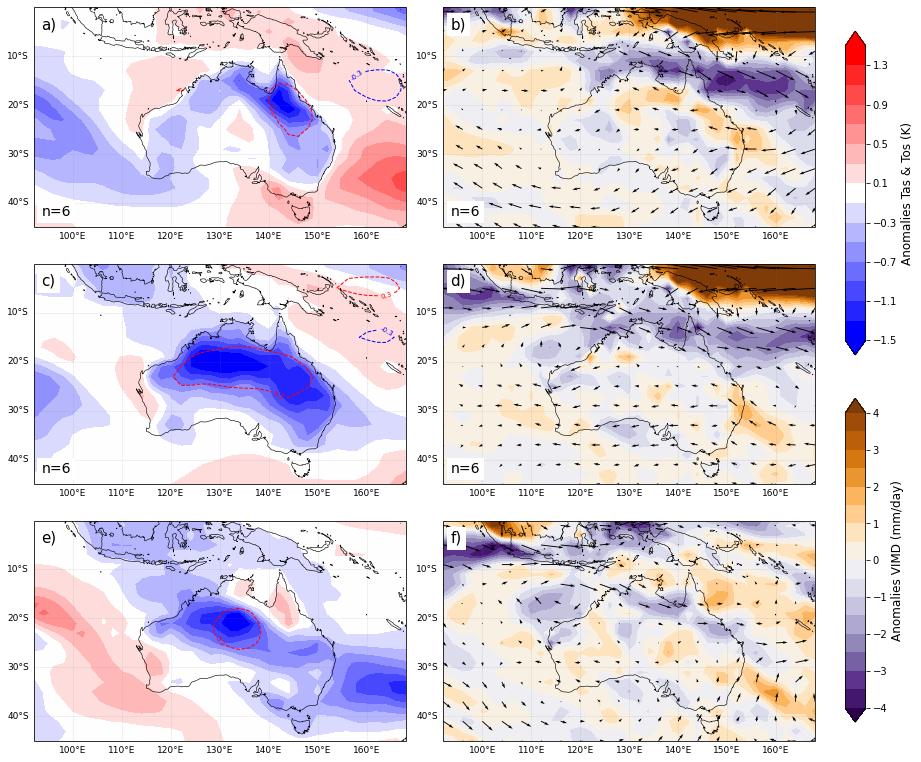

In [13]:
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# --- CONFIGURATION DES PARAMÈTRES ---
# Température & SST
neg_side = np.arange(-1.5, -0.09, 0.2) 
pos_side = np.arange(0.1, 1.51, 0.2)   
lvl_temp = np.concatenate([neg_side, pos_side])
cmap_temp = plt.get_cmap('bwr')
norm_temp = mcolors.BoundaryNorm(boundaries=lvl_temp, ncolors=cmap_temp.N)

# VIMD (Converti en mm/jour ou kg/m2/jour, échelle centrée)
lvl_vimd = np.linspace(-4, 4, 17) 

# Évaporation — contours progressifs
lev_pos_dash   = [0.3]
lev_pos_thin   = [0.6]
lev_pos_thick  = [0.9]
lev_pos_vthick = [1.2]

lev_neg_dash   = [-0.3]
lev_neg_thin   = [-0.6]
lev_neg_thick  = [-0.9]
lev_neg_vthick = [-1.2]

# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def smooth_data(da, sigma=1.5):
    """Lissage gaussien qui gère les NaNs."""
    v = da.values.copy()
    mask = np.isnan(v)
    v[mask] = 0
    v_smooth = gaussian_filter(v, sigma=sigma)
    v_smooth[mask] = np.nan
    return v_smooth

def format_map(ax, label, n_text):
    ax.set_extent([92, 168, -45, 0], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='black', zorder=10)
    ax.text(0.02, 0.9, label, transform=ax.transAxes, fontsize=15,
            bbox=dict(facecolor='white', edgecolor='none', alpha=1), zorder=11)
    if n_text is not None:
        ax.text(0.02, 0.05, f"n={n_text}", transform=ax.transAxes, fontsize=14,
                bbox=dict(facecolor='white', edgecolor='none', alpha=1), zorder=11)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {'size': 9}

# ============================================================
# CALCUL MMM
# ============================================================
seasonal_mmm = {tag_yr1: {}, tag_yr3: {}, tag_diff: {}}

for tag in [tag_yr1, tag_yr3]:
    for var in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
        data_list = all_anoms.get(tag, {}).get(var, [])
        if len(data_list) > 0:
            da_concat = xr.concat(data_list, dim='model_event')
            seasonal_mmm[tag][var] = da_concat.mean(dim='model_event')
            print(f"✅ {tag} - {var} : Moyenne calculée sur {len(data_list)} entrées.")
        else:
            print(f"⚠️ {tag} - {var} : Aucune donnée trouvée !")

for v in ['tas', 'tos', 'ev', 'u850', 'v850', 'vimd']:
    if v in seasonal_mmm[tag_yr3] and v in seasonal_mmm[tag_yr1]:
        seasonal_mmm[tag_diff][v] = seasonal_mmm[tag_yr3][v] - seasonal_mmm[tag_yr1][v]

# ============================================================
# FIGURE
# ============================================================
n_total_events = len(all_anoms[tag_yr1]['tas'])
print(f"\nNombre total d'événements pour le MMM ({SEASON}) : {n_total_events}")

periods       = [tag_yr1, tag_yr3, tag_diff]
labels_periods = [('a)', 'b)'), ('c)', 'd)'), ('e)', 'f)')]

fig, axes = plt.subplots(3, 2, figsize=(14, 15),
                         subplot_kw={'projection': ccrs.PlateCarree()})
plt.subplots_adjust(wspace=0.1, hspace=-0.15)
ax_list = axes.ravel()

for i, tag in enumerate(periods):
    ax_l, ax_r = ax_list[i * 2], ax_list[i * 2 + 1]
    lbl_l, lbl_r = labels_periods[i]
    n_ev = n_total_events if 'diff' not in tag else None

    format_map(ax_l, lbl_l, n_ev)
    format_map(ax_r, lbl_r, n_ev)

    # ----------------------------------------------------------
    # GAUCHE : TOS + TAS (shading) + ÉVAPORATION (contours)
    # ----------------------------------------------------------
    shading_kw = dict(
        transform=ccrs.PlateCarree(), levels=lvl_temp, norm=norm_temp,
        cmap='bwr', add_colorbar=False, add_labels=False, extend='both'
    )

    # SST (zorder=1, en dessous)
    im_temp = seasonal_mmm[tag]['tos'].plot.contourf(ax=ax_l, zorder=1, **shading_kw)
    # TAS par-dessus (zorder=2)
    seasonal_mmm[tag]['tas'].plot.contourf(ax=ax_l, zorder=2, **shading_kw)

    # Évaporation lissée
    ev_da     = seasonal_mmm[tag]['ev']
    ev_smooth = smooth_data(ev_da, sigma=1.5)
    lons, lats = ev_da.lon, ev_da.lat

    common_ev = dict(transform=ccrs.PlateCarree(), zorder=8)
    label_ev  = dict(inline=True, fontsize=7, fmt='%1.1f', inline_spacing=3)

    # Positifs (Rouge)
    cp1 = ax_l.contour(lons, lats, ev_smooth, levels=lev_pos_dash,   colors='red', linestyles='--', linewidths=1.0, **common_ev)
    cp2 = ax_l.contour(lons, lats, ev_smooth, levels=lev_pos_thin,   colors='red', linestyles='-',  linewidths=1.0, **common_ev)
    cp3 = ax_l.contour(lons, lats, ev_smooth, levels=lev_pos_thick,  colors='red', linestyles='-',  linewidths=1.5, **common_ev)
    cp4 = ax_l.contour(lons, lats, ev_smooth, levels=lev_pos_vthick, colors='red', linestyles='-',  linewidths=2.0, **common_ev)

    # Négatifs (Bleu)
    cn1 = ax_l.contour(lons, lats, ev_smooth, levels=lev_neg_dash,   colors='blue', linestyles='--', linewidths=1.0, **common_ev)
    cn2 = ax_l.contour(lons, lats, ev_smooth, levels=lev_neg_thin,   colors='blue', linestyles='-',  linewidths=1.0, **common_ev)
    cn3 = ax_l.contour(lons, lats, ev_smooth, levels=lev_neg_thick,  colors='blue', linestyles='-',  linewidths=1.5, **common_ev)
    cn4 = ax_l.contour(lons, lats, ev_smooth, levels=lev_neg_vthick, colors='blue', linestyles='-',  linewidths=2.0, **common_ev)

    for c in [cp1, cp2, cp3, cp4, cn1, cn2, cn3, cn4]:
        ax_l.clabel(c, **label_ev)

    # ----------------------------------------------------------
    # DROITE : VIMD (shading) + VENTS 850 hPa (vecteurs)
    # ----------------------------------------------------------
    im_vimd = seasonal_mmm[tag]['vimd'].plot.contourf(
        ax=ax_r, transform=ccrs.PlateCarree(), levels=lvl_vimd,
        cmap='PuOr_r', add_colorbar=False, add_labels=False, extend='both', zorder=1
    )

    u_p  = seasonal_mmm[tag]['u850']
    v_p  = seasonal_mmm[tag]['v850']
    skip = (slice(None, None, 2), slice(None, None, 2))

    Q = ax_r.quiver(
        u_p.lon.values[skip[1]], u_p.lat.values[skip[0]],
        u_p.values[skip], v_p.values[skip],
        scale=35, width=0.0025, color='black',
        transform=ccrs.PlateCarree(), zorder=10
    )

# ============================================================
# COLORBARS ET LÉGENDES
# ============================================================
cax1 = fig.add_axes([0.93, 0.52, 0.02, 0.3])
fig.colorbar(im_temp, cax=cax1).set_label('Anomalies Tas & Tos (K)', size=12)

cax2 = fig.add_axes([0.93, 0.18, 0.02, 0.3])
fig.colorbar(im_vimd, cax=cax2).set_label('Anomalies VIMD (mm/day)', size=12)

ax_list[5].quiverkey(Q, X=1.1, Y=-0.12, U=1, label='1 m/s',
                     labelpos='S', coordinates='axes')

fig.suptitle(f'Triple La Niña — Saison {SEASON}', fontsize=14, y=0.92)
plt.savefig(f'/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/Model_by_Model/MRI-ESM2-0_{SEASON}_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()